# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# BackpropagationNetwork class Implementation

In [2]:
class BackpropagationNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.lr = learning_rate
        self.cost_history = []
        self.gradient_history = {'dW1': [], 'db1': [], 'dW2': [], 'db2': []}

        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, a):
        return a * (1 - a)

    def forward(self, X):
        # Step 1: Hidden layer forward pass
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)

        # Step 2: Output layer forward pass
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

    def backward(self, X, y):
        m = X.shape[0]

        # Step 3: Output layer error (delta for output)
        delta2 = self.a2 - y

        # Step 4: Gradients for output layer weights and bias
        dW2 = (1 / m) * np.dot(self.a1.T, delta2)
        db2 = (1 / m) * np.sum(delta2, axis=0, keepdims=True)

        # Step 5: Propagate error to hidden layer
        delta1 = np.dot(delta2, self.W2.T) * self.sigmoid_derivative(self.a1)

        # Step 6: Gradients for hidden layer weights and bias
        dW1 = (1 / m) * np.dot(X.T, delta1)
        db1 = (1 / m) * np.sum(delta1, axis=0, keepdims=True)

        return dW1, db1, dW2, db2

    def cost(self, y_pred, y_true):
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def fit(self, X, y, iterations=5000, verbose_every=1000):
        y = y.reshape(-1, 1)

        for i in range(iterations):
            y_pred = self.forward(X)
            dW1, db1, dW2, db2 = self.backward(X, y)

            # Store gradient magnitudes for visualization
            self.gradient_history['dW1'].append(np.linalg.norm(dW1))
            self.gradient_history['db1'].append(np.linalg.norm(db1))
            self.gradient_history['dW2'].append(np.linalg.norm(dW2))
            self.gradient_history['db2'].append(np.linalg.norm(db2))

            # Update parameters
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

            self.cost_history.append(self.cost(y_pred, y))

            if verbose_every and (i + 1) % verbose_every == 0:
                print(f"Iteration {i + 1}: Cost = {self.cost_history[-1]:.4f}")
                print(f"  dW1 norm: {self.gradient_history['dW1'][-1]:.4f}, dW2 norm: {self.gradient_history['dW2'][-1]:.4f}")

    def predict(self, X):
        return (self.forward(X) >= 0.5).astype(int)

# Prepare Data (XOR Problem)

In [3]:
# XOR is the classic problem that requires backpropagation through a hidden layer
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

print("XOR Training Data:")
print("X:", X.tolist())
print("y:", y.flatten().tolist())

XOR Training Data:
X: [[0, 0], [0, 1], [1, 0], [1, 1]]
y: [0, 1, 1, 0]


# Train the Model

In [4]:
model = BackpropagationNetwork(input_size=2, hidden_size=4, output_size=1, learning_rate=1.0)
model.fit(X, y, iterations=5000, verbose_every=1000)

Iteration 1000: Cost = 0.0141
  dW1 norm: 0.0021, dW2 norm: 0.0038
Iteration 2000: Cost = 0.0052
  dW1 norm: 0.0008, dW2 norm: 0.0015
Iteration 3000: Cost = 0.0031
  dW1 norm: 0.0005, dW2 norm: 0.0009
Iteration 4000: Cost = 0.0021
  dW1 norm: 0.0004, dW2 norm: 0.0007
Iteration 5000: Cost = 0.0016
  dW1 norm: 0.0003, dW2 norm: 0.0005


# Evaluate the Model

In [5]:
predictions = model.predict(X)
print("\nXOR Predictions:")
for xi, yi, pred in zip(X, y, predictions):
    print(f"  Input: {xi} -> Predicted: {pred[0]}, Actual: {yi[0]}")

accuracy = np.mean(predictions == y)
print(f"\nAccuracy: {accuracy:.2f}")


XOR Predictions:
  Input: [0 0] -> Predicted: 0, Actual: 0
  Input: [0 1] -> Predicted: 1, Actual: 1
  Input: [1 0] -> Predicted: 1, Actual: 1
  Input: [1 1] -> Predicted: 0, Actual: 0

Accuracy: 1.00


# Visualize Backpropagation

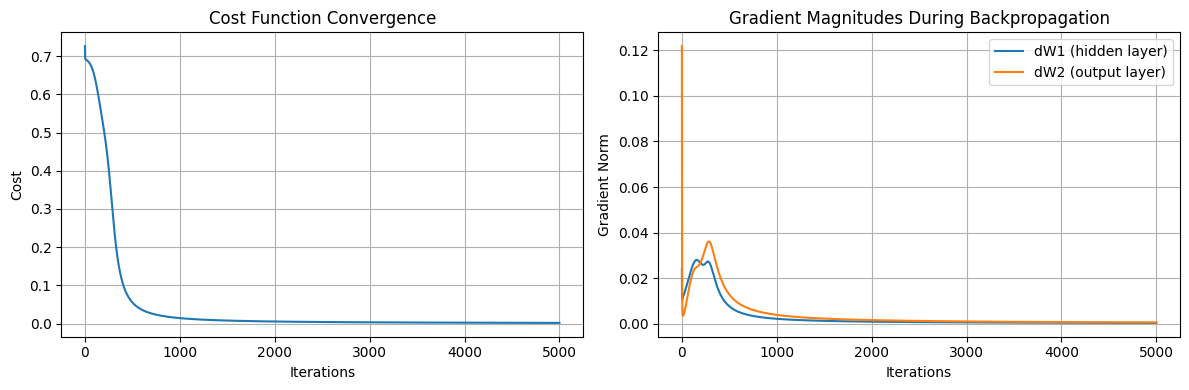

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(model.cost_history)
axes[0].set_title('Cost Function Convergence')
axes[0].set_xlabel('Iterations')
axes[0].set_ylabel('Cost')
axes[0].grid(True)

axes[1].plot(model.gradient_history['dW1'], label='dW1 (hidden layer)')
axes[1].plot(model.gradient_history['dW2'], label='dW2 (output layer)')
axes[1].set_title('Gradient Magnitudes During Backpropagation')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Gradient Norm')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()